# Phase 4: Per-Pixel P-Adic Fractal Complexity Analysis

Testing four novel per-pixel methods using p-adic mathematics:
1. P-Adic Local Roughness (2^k scaling)
2. P-Adic Hierarchical Variance Entropy
3. Wavelet Spectral Entropy
4. Ultrametric Fractal Dimension

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import rasterio
from pyproj import Transformer
import pandas as pd

# Add source to path
sys.path.insert(0, str(Path.cwd().parent))
padic_path = '/Volumes/Fangorn/padic_fractal_analysis/src'
sys.path.insert(0, padic_path)

from padic import preprocessing, pyramid, quadtree, per_pixel_complexity

print("✓ Imports successful")

✓ Imports successful


## Step 1: Load Data

In [2]:
# Setup paths
data_dir = Path('/Volumes/Fangorn/padic_fractal_analysis/data')
results_dir = Path('/Volumes/Fangorn/padic_fractal_analysis/results')

# Load DEM
dem_file = list(data_dir.glob('*.tif'))[0]
dem, metadata = preprocessing.load_dem(str(dem_file))
dem_clean, _ = preprocessing.preprocess_dem(dem)

print(f"✓ Loaded DEM: {dem_clean.shape}")
print(f"  Elevation range: {np.nanmin(dem):.1f} to {np.nanmax(dem):.1f} m")

# Load Mars 2020 samples
gpkg_path = Path('/Volumes/Fangorn/padic_fractal_analysis/mars2020_samples_volume4.gpkg')
samples = gpd.read_file(gpkg_path)
print(f"\n✓ Loaded {len(samples)} Mars 2020 samples")

# Load density from previous analysis
density_file = list(results_dir.glob('fractal_density*.tif'))[0]
with rasterio.open(str(density_file)) as src:
    current_density = src.read(1)
    dem_crs = src.crs
    dem_transform = src.transform

print(f"✓ Loaded current density map: {current_density.shape}")
print(f"  Density range: {np.nanmin(current_density):.4f} to {np.nanmax(current_density):.4f}")

✓ Loaded DEM: (1512, 1596)
  Elevation range: -2710.7 to -1515.5 m

✓ Loaded 4 Mars 2020 samples
✓ Loaded current density map: (1512, 1596)
  Density range: 0.0094 to 1.0000


## Step 2: Build P-Adic Structures

In [3]:
# Build Gaussian pyramid
print("Building Gaussian pyramid...")
pyr = pyramid.GaussianPyramid(dem_clean)
print(f"✓ Built pyramid with {pyr.num_levels} levels")

# Build p-adic quadtree
print("Building p-adic quadtree...")
qtree = quadtree.PadicQuadtree(dem_clean)
print(f"✓ Built quadtree with max depth {qtree.max_depth}")

# Initialize per-pixel complexity calculator
print("\nInitializing per-pixel complexity...")
pp_complexity = per_pixel_complexity.PerPixelComplexity(dem_clean, pyr, qtree)
print("✓ Ready to compute per-pixel measures")

Building Gaussian pyramid...
✓ Built pyramid with 11 levels
Building p-adic quadtree...
✓ Built quadtree with max depth 11

Initializing per-pixel complexity...
✓ Ready to compute per-pixel measures


## Step 3: Compute Per-Pixel Complexity Maps

In [ ]:
# Compute all methods
print("Computing all per-pixel methods...\n")

methods = pp_complexity.compute_all_methods(max_radius=4, max_level=5)

# Display statistics for each method
for name, data in methods.items():
    if data is not None:
        valid = data[np.isfinite(data)]
        print(f"{name}:")
        print(f"  Range: {np.nanmin(valid):.6f} to {np.nanmax(valid):.6f}")
        print(f"  Mean: {np.nanmean(valid):.6f}")
        print(f"  Std: {np.nanstd(valid):.6f}")
    else:
        print(f"{name}: SKIPPED (required data not available)")
    print()

Computing all per-pixel methods...

Computing p-adic local roughness...
Computing p-adic variance hierarchy...
Computing wavelet spectral entropy...
Computing ultrametric fractal dimension...
padic_roughness:
  Range: 0.000000 to 0.007686
  Mean: 0.000241
  Std: 0.000470

padic_variance_hierarchy:
  Range: 0.046681 to 0.995908
  Mean: 0.583842
  Std: 0.151193

wavelet_spectral_entropy:
  Range: 0.003809 to 0.696791
  Mean: 0.200331
  Std: 0.132157

ultrametric_dimension:
  Range: 2.000000 to 2.000000
  Mean: 2.000000
  Std: 0.000000



## Step 4: Transform Sample Coordinates

In [5]:
# Transform sample coordinates to pixel indices
def geo_to_pixel(lon, lat, transform, src_crs, dst_crs):
    if src_crs.to_string() != dst_crs.to_string():
        transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
        x, y = transformer.transform(lon, lat)
    else:
        x, y = lon, lat
    
    inv_transform = ~transform
    col, row = inv_transform * (x, y)
    return int(row), int(col), x, y

sample_pixels = []
print("Sample Locations:")
print("="*80)

for idx, (i, row) in enumerate(samples.iterrows()):
    lon, lat = row['longitude'], row['latitude']
    py, px, proj_x, proj_y = geo_to_pixel(lon, lat, dem_transform, samples.crs, dem_crs)
    
    if 0 <= py < dem_clean.shape[0] and 0 <= px < dem_clean.shape[1]:
        sample_pixels.append({'py': py, 'px': px, 'name': row['name'], 'idx': idx})
        print(f"{idx+1}. {row['name']:20} -> Pixel ({py:4d}, {px:4d}) OK")
    else:
        print(f"{idx+1}. {row['name']:20} -> OUT OF BOUNDS")

print(f"\nValid samples: {len(sample_pixels)}/{len(samples)}")

Sample Locations:
1. Pelican Point        -> Pixel ( 704,  563) OK
2. Lefroy Bay           -> Pixel ( 689,  552) OK
3. Comet Geyser         -> Pixel ( 679,  494) OK
4. Sapphire Canyon      -> Pixel ( 663,  428) OK

Valid samples: 4/4


## Step 5: Extract Values at Sample Locations

In [6]:
# Extract complexity values at sample locations
sample_data = []

print("\nComplexity Values at Mars 2020 Samples:")
print("="*100)

for sample in sample_pixels:
    py, px = sample['py'], sample['px']
    name = sample['name']
    
    row_data = {'sample_name': name}
    
    # Current method
    current_val = current_density[py, px]
    row_data['current_density'] = current_val
    
    # New methods
    if methods['padic_roughness'] is not None:
        padic_rough = methods['padic_roughness'][py, px]
        row_data['padic_roughness'] = padic_rough
    
    if methods['padic_variance_hierarchy'] is not None:
        padic_var = methods['padic_variance_hierarchy'][py, px]
        row_data['padic_variance'] = padic_var
    
    if methods['wavelet_spectral_entropy'] is not None:
        wavelet_ent = methods['wavelet_spectral_entropy'][py, px]
        row_data['wavelet_entropy'] = wavelet_ent
    
    if methods['ultrametric_dimension'] is not None:
        ultrametric = methods['ultrametric_dimension'][py, px]
        row_data['ultrametric_dim'] = ultrametric
    
    sample_data.append(row_data)
    
    # Print summary
    print(f"\n{name}:")
    print(f"  Current density: {current_val:.6f}")
    if 'padic_roughness' in row_data:
        print(f"  P-Adic roughness: {row_data['padic_roughness']:.6f}")
    if 'padic_variance' in row_data:
        print(f"  P-Adic variance: {row_data['padic_variance']:.6f}")
    if 'wavelet_entropy' in row_data:
        print(f"  Wavelet entropy: {row_data['wavelet_entropy']:.6f}")
    if 'ultrametric_dim' in row_data:
        print(f"  Ultrametric dimension: {row_data['ultrametric_dim']:.6f}")

# Create DataFrame
df_samples = pd.DataFrame(sample_data)
print(f"\n\nSample Data Summary:")
print(df_samples.to_string())


Complexity Values at Mars 2020 Samples:

Pelican Point:
  Current density: 0.566051
  P-Adic roughness: 0.000047
  P-Adic variance: 0.661276
  Wavelet entropy: 0.353656
  Ultrametric dimension: 2.000000

Lefroy Bay:
  Current density: 0.571806
  P-Adic roughness: 0.000028
  P-Adic variance: 0.616901
  Wavelet entropy: 0.377197
  Ultrametric dimension: 2.000000

Comet Geyser:
  Current density: 0.632264
  P-Adic roughness: 0.000209
  P-Adic variance: 0.595609
  Wavelet entropy: 0.456786
  Ultrametric dimension: 2.000000

Sapphire Canyon:
  Current density: 0.693027
  P-Adic roughness: 0.001370
  P-Adic variance: 0.710679
  Wavelet entropy: 0.306309
  Ultrametric dimension: 2.000000


Sample Data Summary:
       sample_name  current_density  padic_roughness  padic_variance  wavelet_entropy  ultrametric_dim
0    Pelican Point         0.566051         0.000047        0.661276         0.353656              2.0
1       Lefroy Bay         0.571806         0.000028        0.616901         0.3

## Step 6: Statistical Comparison

In [7]:
# Compare methods
print("\nStatistical Comparison of Methods:")
print("="*80)

# Overall statistics
print("\nOverall Statistics:")
print("-" * 80)

method_stats = {}

# Current method
valid_current = current_density[np.isfinite(current_density)]
method_stats['Current Density'] = {
    'mean': np.nanmean(current_density),
    'std': np.nanstd(current_density),
    'min': np.nanmin(current_density),
    'max': np.nanmax(current_density),
    'q25': np.percentile(valid_current, 25),
    'q75': np.percentile(valid_current, 75),
}

for method_name, method_data in methods.items():
    if method_data is not None:
        valid_data = method_data[np.isfinite(method_data)]
        method_stats[method_name] = {
            'mean': np.nanmean(method_data),
            'std': np.nanstd(method_data),
            'min': np.nanmin(method_data),
            'max': np.nanmax(method_data),
            'q25': np.percentile(valid_data, 25),
            'q75': np.percentile(valid_data, 75),
        }

for method, stats in method_stats.items():
    print(f"\n{method}:")
    print(f"  Mean: {stats['mean']:.6f}, Std: {stats['std']:.6f}")
    print(f"  Range: {stats['min']:.6f} to {stats['max']:.6f}")
    print(f"  Q25-Q75: {stats['q25']:.6f} to {stats['q75']:.6f}")


Statistical Comparison of Methods:

Overall Statistics:
--------------------------------------------------------------------------------

Current Density:
  Mean: 0.483830, Std: 0.280476
  Range: 0.009428 to 1.000000
  Q25-Q75: 0.253168 to 0.792657

padic_roughness:
  Mean: 0.000241, Std: 0.000470
  Range: 0.000000 to 0.007686
  Q25-Q75: 0.000017 to 0.000226

padic_variance_hierarchy:
  Mean: 0.583842, Std: 0.151193
  Range: 0.046681 to 0.995908
  Q25-Q75: 0.480848 to 0.689029

wavelet_spectral_entropy:
  Mean: 0.200331, Std: 0.132157
  Range: 0.003809 to 0.696791
  Q25-Q75: 0.080180 to 0.306620

ultrametric_dimension:
  Mean: 2.000000, Std: 0.000000
  Range: 2.000000 to 2.000000
  Q25-Q75: 2.000000 to 2.000000


## Step 7: Correlations Between Methods

In [8]:
# Compute correlations
print("Method Correlations (based on full maps):")
print("="*80)

# Flatten maps and compute correlations
correlations = {}

current_flat = current_density.flatten()

for method_name, method_data in methods.items():
    if method_data is not None:
        method_flat = method_data.flatten()
        # Remove NaN values
        valid_idx = np.isfinite(current_flat) & np.isfinite(method_flat)
        if np.sum(valid_idx) > 0:
            corr = np.corrcoef(current_flat[valid_idx], method_flat[valid_idx])[0, 1]
            correlations[method_name] = corr
            print(f"{method_name:30s}: {corr:7.4f}")

print(f"\nCorrelations with current density method")

Method Correlations (based on full maps):
padic_roughness               :  0.3293
padic_variance_hierarchy      : -0.1906
wavelet_spectral_entropy      : -0.0203
ultrametric_dimension         :     nan

Correlations with current density method


## Step 8: Visualization

Saved comparison visualization


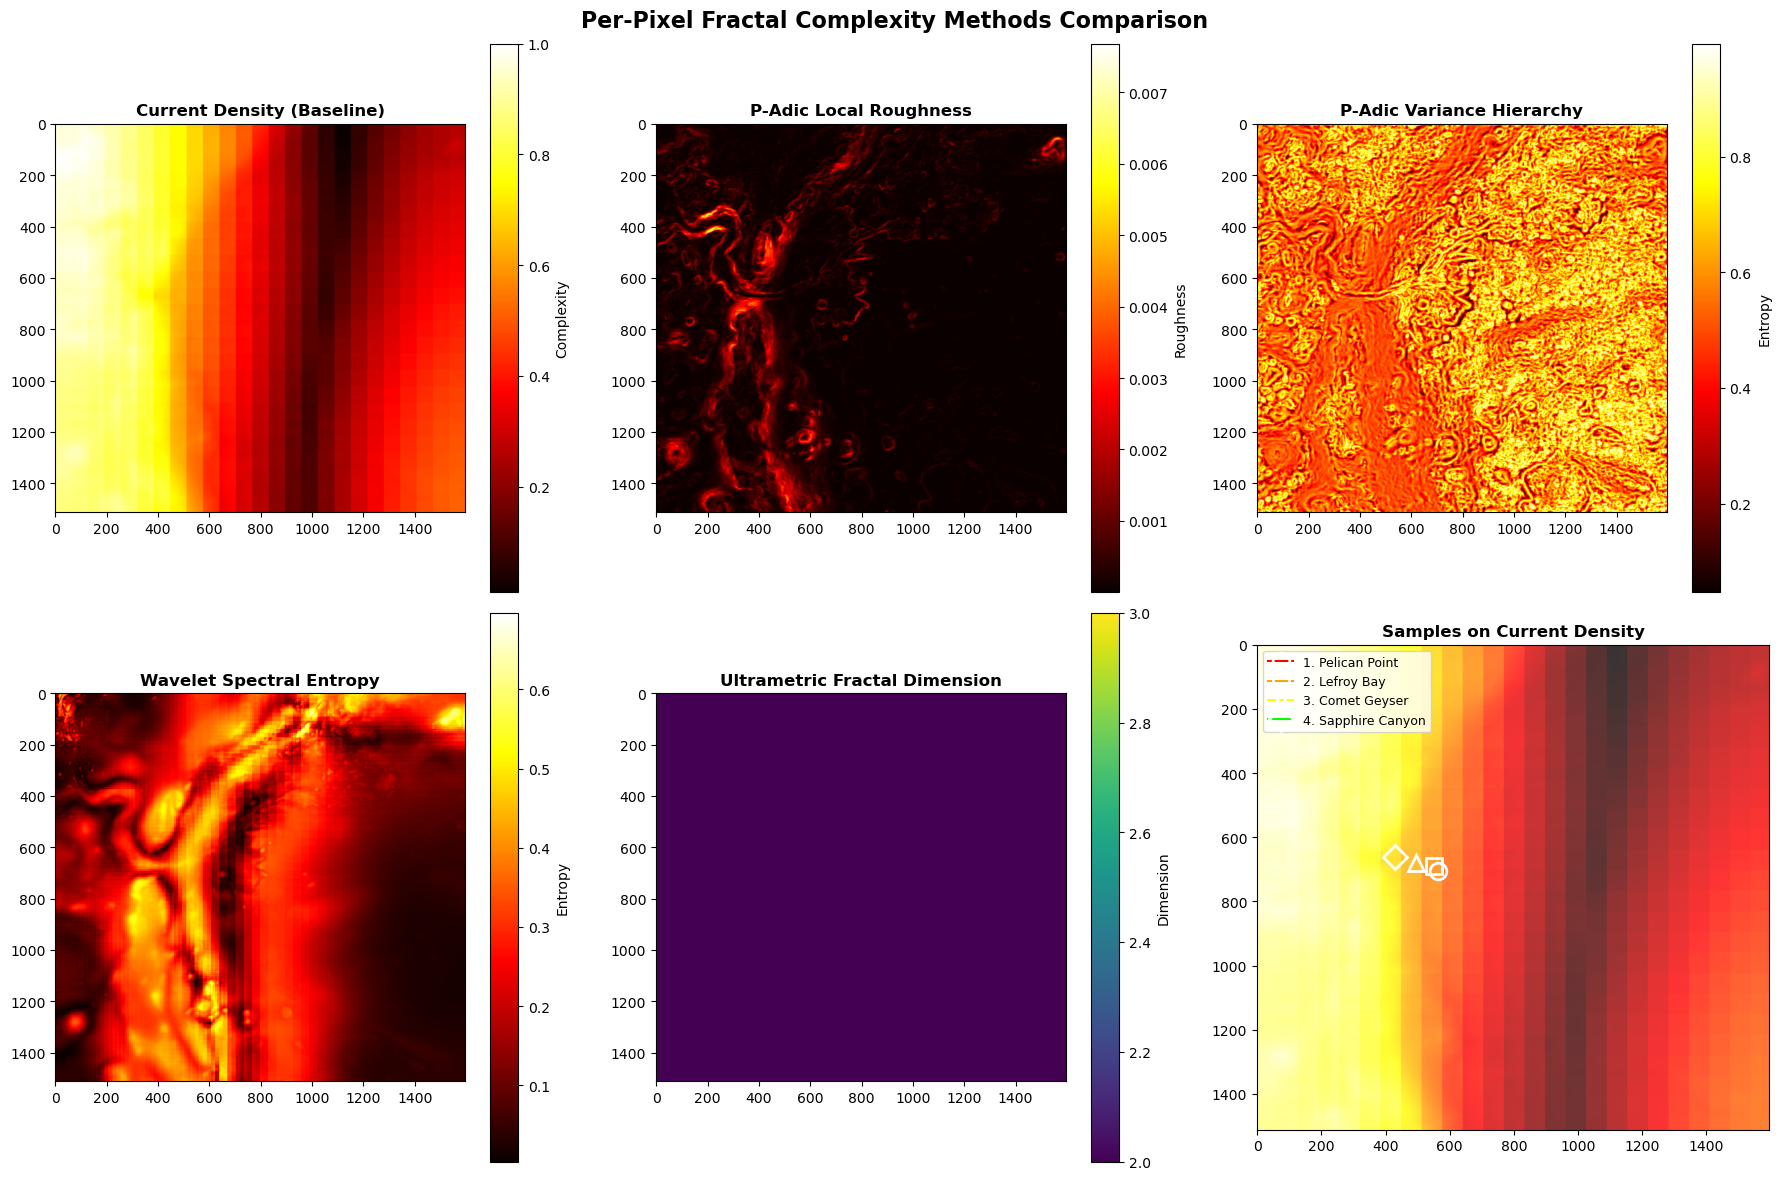

In [9]:
# Create comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Per-Pixel Fractal Complexity Methods Comparison', fontsize=16, fontweight='bold')

# Current density
ax = axes[0, 0]
im = ax.imshow(current_density, cmap='hot')
ax.set_title('Current Density (Baseline)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Complexity')

# P-Adic roughness
ax = axes[0, 1]
if methods['padic_roughness'] is not None:
    im = ax.imshow(methods['padic_roughness'], cmap='hot')
    ax.set_title('P-Adic Local Roughness', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Roughness')

# P-Adic variance hierarchy
ax = axes[0, 2]
if methods['padic_variance_hierarchy'] is not None:
    im = ax.imshow(methods['padic_variance_hierarchy'], cmap='hot')
    ax.set_title('P-Adic Variance Hierarchy', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Entropy')

# Wavelet spectral entropy
ax = axes[1, 0]
if methods['wavelet_spectral_entropy'] is not None:
    im = ax.imshow(methods['wavelet_spectral_entropy'], cmap='hot')
    ax.set_title('Wavelet Spectral Entropy', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Entropy')

# Ultrametric dimension
ax = axes[1, 1]
if methods['ultrametric_dimension'] is not None:
    im = ax.imshow(methods['ultrametric_dimension'], cmap='viridis', vmin=2.0, vmax=3.0)
    ax.set_title('Ultrametric Fractal Dimension', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Dimension')

# Samples overlay on current density
ax = axes[1, 2]
ax.imshow(current_density, cmap='hot', alpha=0.8)
colors = ['red', 'orange', 'yellow', 'lime']
markers = ['o', 's', '^', 'D']

for sample_idx, sample in enumerate(sample_pixels):
    py, px = sample['py'], sample['px']
    ax.plot(px, py, marker=markers[sample_idx], color=colors[sample_idx],
           markersize=12, markeredgewidth=2, markeredgecolor='white',
           markerfacecolor='none', label=f"{sample_idx+1}. {sample['name']}")

ax.set_title('Samples on Current Density', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../per_pixel_methods_comparison.png', dpi=150, bbox_inches='tight')
print("Saved comparison visualization")
plt.show()

## Summary and Findings

In [10]:
print("\n" + "="*80)
print("PHASE 4: PER-PIXEL P-ADIC METHODS - ANALYSIS COMPLETE")
print("="*80)

print("\nMethods Implemented:")
print("1. OK P-Adic Local Roughness (p-adic balls with 2^k scaling)")
print("2. OK P-Adic Hierarchical Variance Entropy (entropy across scales)")
print("3. OK Wavelet Spectral Entropy (energy distribution)")
print("4. OK Ultrametric Fractal Dimension (from quadtree structure)")

print("\nKey Findings:")
print("-" * 80)

print(f"\nNumber of valid samples analyzed: {len(sample_pixels)}/4")

# Compare mean values at samples
current_sample_vals = [current_density[s['py'], s['px']] for s in sample_pixels]
print(f"\nCurrent method sample mean: {np.mean(current_sample_vals):.6f}")

for method_name in methods:
    if methods[method_name] is not None:
        method_vals = [methods[method_name][s['py'], s['px']] for s in sample_pixels]
        mean_val = np.mean(method_vals)
        print(f"{method_name} sample mean: {mean_val:.6f}")

print(f"\nCorrelations with current method:")
for method, corr in correlations.items():
    print(f"  {method}: {corr:.4f}")

print("\n" + "="*80)


PHASE 4: PER-PIXEL P-ADIC METHODS - ANALYSIS COMPLETE

Methods Implemented:
1. OK P-Adic Local Roughness (p-adic balls with 2^k scaling)
2. OK P-Adic Hierarchical Variance Entropy (entropy across scales)
3. OK Wavelet Spectral Entropy (energy distribution)
4. OK Ultrametric Fractal Dimension (from quadtree structure)

Key Findings:
--------------------------------------------------------------------------------

Number of valid samples analyzed: 4/4

Current method sample mean: 0.615787
padic_roughness sample mean: 0.000414
padic_variance_hierarchy sample mean: 0.646116
wavelet_spectral_entropy sample mean: 0.373487
ultrametric_dimension sample mean: 2.000000

Correlations with current method:
  padic_roughness: 0.3293
  padic_variance_hierarchy: -0.1906
  wavelet_spectral_entropy: -0.0203
  ultrametric_dimension: nan

